# 01 — Entropy & Cross-Entropy

**A note on references for this subchapter:** unlike the previous three, neither of your uploaded books has a dedicated information theory treatment — *Mathematics for Machine Learning* only mentions KL divergence in passing (a "Further Reading" aside, p.~94, pointing to Amari 2016) and uses negative entropy once as an example convex function (Ch.7); *Practical Statistics for Data Scientists* covers entropy only as a decision-tree impurity measure (Ch.6, "Measuring Homogeneity or Impurity" — cited directly in notebook 3). The core definitions here follow the standard treatment found in Cover & Thomas, *Elements of Information Theory*, or the freely available MacKay, *Information Theory, Inference, and Learning Algorithms* (2003) — which is in fact the exact book MML itself cites for mutual information.

Part of the Math Foundations chapter of the 6-month ML Engineer prep plan.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

## Entropy: how much uncertainty (or information) is in a distribution

Shannon entropy measures the average "surprise" of a distribution:

```
H(p) = -Σ p(x) log₂ p(x)
```

Measured in bits (using `log₂`) or nats (using natural log). Intuition: an outcome you were very confident about carries little information when it happens (unsurprising); a coin flip you had no idea about carries a lot of information once you see the result. Entropy is the *expected* amount of information/surprise, averaged over the distribution.

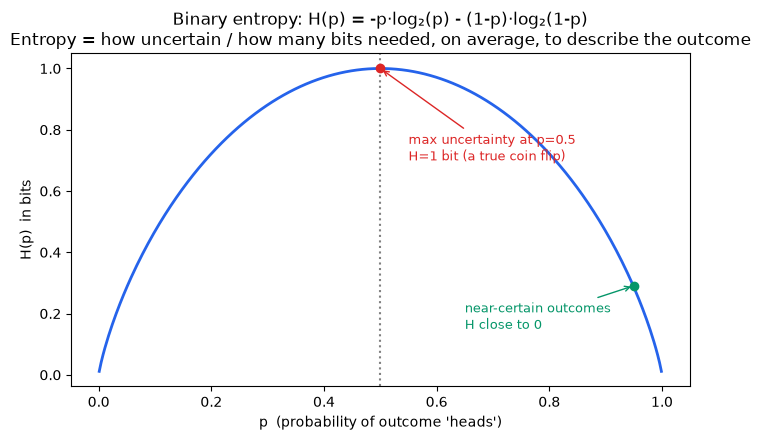

In [2]:
def visualize_binary_entropy(savepath: Path = None):
    p = np.linspace(0.001, 0.999, 300)
    H = -(p * np.log2(p) + (1 - p) * np.log2(1 - p))

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(p, H, color="#2563eb", linewidth=2)
    ax.axvline(0.5, color="gray", linestyle=":")
    ax.scatter([0.5], [1.0], color="#dc2626", zorder=5)
    ax.annotate("max uncertainty at p=0.5\nH=1 bit (a true coin flip)", xy=(0.5, 1.0),
                xytext=(0.55, 0.7), fontsize=9, color="#dc2626",
                arrowprops=dict(arrowstyle="->", color="#dc2626"))
    idx95 = np.argmin(np.abs(p - 0.95))
    ax.scatter([0.95], [H[idx95]], color="#059669", zorder=5)
    ax.annotate("near-certain outcomes\nH close to 0", xy=(0.95, H[idx95]),
                xytext=(0.65, 0.15), fontsize=9, color="#059669",
                arrowprops=dict(arrowstyle="->", color="#059669"))
    ax.set_xlabel("p  (probability of outcome \'heads\')")
    ax.set_ylabel("H(p)  in bits")
    ax.set_title("Binary entropy: H(p) = -p·log₂(p) - (1-p)·log₂(1-p)\nEntropy = how uncertain / how many bits needed, on average, to describe the outcome")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    plt.show()

visualize_binary_entropy(FIG_DIR / "binary_entropy.png")

A fair coin (p=0.5) is maximally unpredictable — 1 full bit of uncertainty per flip. A heavily biased coin (p near 0 or 1) is nearly predictable — almost no uncertainty, almost no information gained by observing it. This exact curve is what a decision tree is trying to *reduce* at every split (notebook 3), and it's the reason a model that's very confident but wrong is penalized so much more harshly than one that's cautiously wrong — which brings us to cross-entropy.

## Cross-entropy: measuring one distribution with another's code

Entropy `H(p)` is the average number of bits needed to encode outcomes from `p`, using the *optimal* code for `p`. **Cross-entropy** asks: what if you encode outcomes from the true distribution `p`, but using a code built for a different (possibly wrong) distribution `q`?

```
H(p, q) = -Σ p(x) log₂ q(x)
```

Because the code isn't optimal for the actual data-generating distribution, `H(p, q) ≥ H(p)` always — using the wrong code can only cost you *more* bits on average, never fewer. That gap is exactly KL divergence (next notebook).

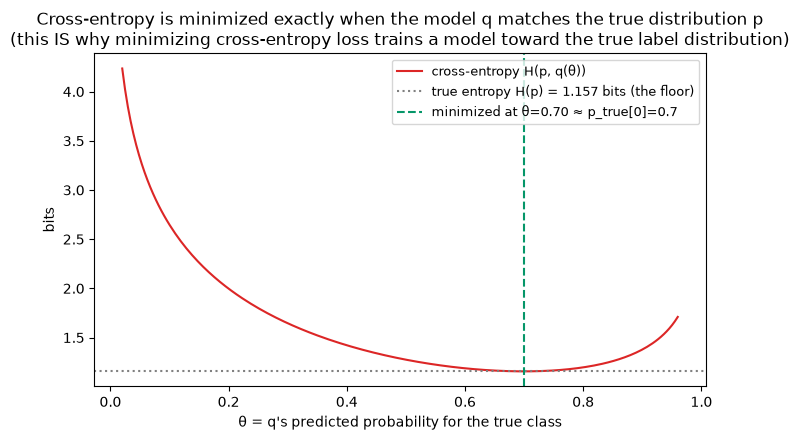

True entropy H(p) = 1.1568 bits; cross-entropy minimized at θ = 0.7002


In [3]:
def visualize_cross_entropy_minimized_at_truth(savepath: Path = None):
    p_true = np.array([0.7, 0.2, 0.1])   # true label distribution, fixed
    H_p = -np.sum(p_true * np.log2(p_true))

    thetas = np.linspace(0.02, 0.96, 200)
    cross_ents = []
    for theta in thetas:
        remaining = 1 - theta
        q = np.array([theta, remaining * 2/3, remaining * 1/3])
        q = np.clip(q, 1e-9, 1)
        cross_ents.append(-np.sum(p_true * np.log2(q)))
    cross_ents = np.array(cross_ents)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(thetas, cross_ents, color="#dc2626", label="cross-entropy H(p, q(θ))")
    ax.axhline(H_p, color="gray", linestyle=":", label=f"true entropy H(p) = {H_p:.3f} bits (the floor)")
    best_idx = np.argmin(cross_ents)
    ax.axvline(thetas[best_idx], color="#059669", linestyle="--",
               label=f"minimized at θ={thetas[best_idx]:.2f} ≈ p_true[0]={p_true[0]}")
    ax.set_xlabel("θ = q\'s predicted probability for the true class")
    ax.set_ylabel("bits")
    ax.legend(fontsize=9)
    ax.set_title("Cross-entropy is minimized exactly when the model q matches the true distribution p\n(this IS why minimizing cross-entropy loss trains a model toward the true label distribution)")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    plt.show()
    return H_p, thetas[best_idx]

H_p, best_theta = visualize_cross_entropy_minimized_at_truth(FIG_DIR / "cross_entropy_minimum.png")
print(f"True entropy H(p) = {H_p:.4f} bits; cross-entropy minimized at θ = {best_theta:.4f}")

The cross-entropy curve bottoms out exactly where the model's predicted probability matches the true class frequency — the floor it approaches is the true entropy `H(p)` itself, which is the irreducible uncertainty even a perfect model can't beat (analogous to the irreducible noise term from the bias-variance decomposition in the Statistics chapter).

**This is precisely why cross-entropy is the standard classification loss**, and it isn't an arbitrary choice: minimizing `H(p, q)` over your model's parameters is *identical* to Maximum Likelihood Estimation. If `p` is the one-hot true label and `q` is your model's predicted distribution, `H(p, q) = -log q(true class)` — exactly the negative log-likelihood from the MLE notebook in the Statistics chapter. Cross-entropy loss, softmax + cross-entropy's gradient (from the Calculus chapter), and MLE (from the Statistics chapter) are three views of the exact same underlying idea.

---

## Self-check before moving on

- [ ] I can state the entropy formula and explain it as "expected surprise" or "average bits needed"
- [ ] I can explain why entropy is maximized for a uniform/fair distribution and minimized for a certain outcome
- [ ] I can state the cross-entropy formula and explain why `H(p,q) ≥ H(p)` always
- [ ] I can explain why minimizing cross-entropy loss is equivalent to Maximum Likelihood Estimation

Next: `02-kl-divergence-mutual-information.ipynb` ⭐